In [1]:
!nvidia-smi

Mon Aug 17 22:06:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!rm -rf /content/seq-models-03-mechinterp-typoglycemia/

In [6]:
!git clone https://github.com/Dorcas-Joy-Kahunguka/seq-models-03-mechinterp-typoglycemia
%cd  /content/seq-models-03-mechinterp-typoglycemia/


Cloning into 'seq-models-03-mechinterp-typoglycemia'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 29 (delta 2), reused 29 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 85.92 KiB | 733.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/seq-models-03-mechinterp-typoglycemia


In [7]:
import os
print(os.getcwd())

/content/seq-models-03-mechinterp-typoglycemia


In [8]:
%pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.7 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=f8637e92027a6aa272122bedfdb33a5d4fb77bfa01377f9f3e21466843a37ee2
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator


In [9]:
import transformer_lens
from transformer_lens import HookedTransformer

import sys
sys.path.append("/content")

import threading
from concurrent.futures import ThreadPoolExecutor
from src.data_utils import load_json_dataset
from src import behavioural_utils as bu

import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

import torch
import json
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt





[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [10]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [11]:
CACHE_DIR = "/content/drive/MyDrive/scramble_exps"

import os
os.makedirs(CACHE_DIR, exist_ok=True)

In [12]:
TOP_K = 5


@torch.no_grad()
def predict_next_word(model, sentence, top_k=TOP_K):
    """
    Run `model` on `sentence` and return the top-k predicted next tokens
    (decoded to strings, stripped) along with their probabilities, for the
    final token position.
    """
    tokens = model.to_tokens(sentence, prepend_bos=True)
    logits, cache = model.run_with_cache(tokens)
    last_logits = logits[0, -1]
    probs = torch.softmax(last_logits, dim=-1)
    top_probs, top_ids = probs.topk(top_k)
    words = [model.tokenizer.decode([tid]).strip() for tid in top_ids.tolist()]

    pred = {
            "top1": words[0],
            "top_k_words": words,
            "top_k_probs": top_probs.tolist(),
        }

    internals = {
        "tokens": tokens.cpu(),
        "str_tokens": model.to_str_tokens(sentence, prepend_bos=True),
        "logits": logits.cpu().half(),
        "cache": {k: v.cpu().half() for k, v in cache.items()},
    }

    return pred,internals 
    


def predict_pair(idx):
    """Run clean + scrambled prediction for one pair concurrently on two threads."""
    with ThreadPoolExecutor(max_workers=2) as executor:
        fut_clean = executor.submit(predict_next_word, model_clean, clean_sentences[idx])
        fut_scrambled = executor.submit(predict_next_word, model_scrambled, scrambled_sentences[idx])
        return fut_clean.result(), fut_scrambled.result()

In [13]:
MODEL_NAME = "gpt2-small"  
device = "cuda" if torch.cuda.is_available() else "cpu"

model_clean = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model_scrambled = HookedTransformer.from_pretrained(MODEL_NAME, device=device)

model_clean.eval()
model_scrambled.eval()
print("Loaded two model instances on", device)



/tmp/ipykernel_1312/4131083537.py:4: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model_clean = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


/tmp/ipykernel_1312/4131083537.py:5: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model_scrambled = HookedTransformer.from_pretrained(MODEL_NAME, device=device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Loaded two model instances on cuda


In [ ]:
with open("/content/drive/MyDrive/scramble_exps/bos_token.json", "w") as f: 
    json.dump({"bos_token_id": model_clean.tokenizer.bos_token_id, "bos_token": model_clean.tokenizer.bos_token}, f) 
print(f"Saved bos_token.json: {model_clean.tokenizer.bos_token!r}")

#files.download("bos_token.json")

Saved bos_token.json: '<|endoftext|>'


In [15]:
ids, clean_sentences, scrambled_sentences, target_words = load_json_dataset("data/processed/clean.json", "data/processed/scramble.json","data/processed/target.json")
print("ids", ids)
print("clean_sentences", clean_sentences)
print("scrambled_sentences", scrambled_sentences)
print("target_words", target_words)

ids ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']
clean_sentences ['The quick brown fox jumps over the lazy', 'My Mum tries to be cool by saying that she likes all the same things that I', "If you like tuna and tomato sauce, try combining the two. It's really not as bad as it", "Someone I know recently combined Maple Syrup and buttered Popcorn thinking it would taste like caramel popcorn. It didn't and they don't recommend anyone else do it", "Sometim

In [16]:
records = []
for i in range(len(ids)):
    (clean_pred, clean_internals), (scrambled_pred, scrambled_internals) = predict_pair(i)

    cache_path = f"{CACHE_DIR}/{ids[i]}.pt"

    torch.save({
    "id": ids[i],
    "clean_sentence": clean_sentences[i],
    "scrambled_sentence": scrambled_sentences[i],
    "clean": clean_internals,
    "scrambled": scrambled_internals,
    },
    cache_path,)

    records.append({
        "id": ids[i],
        "clean_sentence": clean_sentences[i],
        "scrambled_sentence": scrambled_sentences[i],
        "target_word": target_words[i],
        "clean_top1": clean_pred["top1"],
        "clean_top_k": clean_pred["top_k_words"],
        "scrambled_top1": scrambled_pred["top1"],
        "scrambled_top_k": scrambled_pred["top_k_words"],
        "cache_path": cache_path,
    })
    if (i + 1) % 25 == 0:
        print(f"{i + 1}/{len(ids)} pairs done")

print("Done:", len(records), "pairs predicted.")
print(records)

25/100 pairs done
50/100 pairs done
75/100 pairs done
100/100 pairs done
Done: 100 pairs predicted.
[{'id': '0', 'clean_sentence': 'The quick brown fox jumps over the lazy', 'scrambled_sentence': 'The qucik brwon fox jpmus oevr the lzay', 'target_word': 'dog', 'clean_top1': ',', 'clean_top_k': [',', 'fox', 'dog', 'brown', 'white'], 'scrambled_top1': 't', 'scrambled_top_k': ['t', 'k', 'r', 'd', 'u'], 'cache_path': '/content/drive/MyDrive/scramble_exps/0.pt'}, {'id': '1', 'clean_sentence': 'My Mum tries to be cool by saying that she likes all the same things that I', 'scrambled_sentence': 'My Mum tiers to be cool by syinag taht she lieks all the smae thgins taht I', 'target_word': 'do', 'clean_top1': 'do', 'clean_top_k': ['do', 'like', 'love', 'have', 'did'], 'scrambled_top1': 'have', 'scrambled_top_k': ['have', "'m", 'can', 'will', 'know'], 'cache_path': '/content/drive/MyDrive/scramble_exps/1.pt'}, {'id': '10', 'clean_sentence': "If you like tuna and tomato sauce, try combining the two

In [17]:
for r in records:
    r["pred_cosine_sim"] = bu.word_cosine_relatedness(model_clean, r["clean_top1"], r["scrambled_top1"])
    r["pred_wordnet_wup"] = bu.wordnet_relatedness(r["clean_top1"], r["scrambled_top1"], metric="wup")
    r["pred_wordnet_path"] = bu.wordnet_relatedness(r["clean_top1"], r["scrambled_top1"], metric="path")

print(records)

[{'id': '0', 'clean_sentence': 'The quick brown fox jumps over the lazy', 'scrambled_sentence': 'The qucik brwon fox jpmus oevr the lzay', 'target_word': 'dog', 'clean_top1': ',', 'clean_top_k': [',', 'fox', 'dog', 'brown', 'white'], 'scrambled_top1': 't', 'scrambled_top_k': ['t', 'k', 'r', 'd', 'u'], 'cache_path': '/content/drive/MyDrive/scramble_exps/0.pt', 'pred_cosine_sim': 0.31080836057662964, 'pred_wordnet_wup': None, 'pred_wordnet_path': None}, {'id': '1', 'clean_sentence': 'My Mum tries to be cool by saying that she likes all the same things that I', 'scrambled_sentence': 'My Mum tiers to be cool by syinag taht she lieks all the smae thgins taht I', 'target_word': 'do', 'clean_top1': 'do', 'clean_top_k': ['do', 'like', 'love', 'have', 'did'], 'scrambled_top1': 'have', 'scrambled_top_k': ['have', "'m", 'can', 'will', 'know'], 'cache_path': '/content/drive/MyDrive/scramble_exps/1.pt', 'pred_cosine_sim': 0.6535342931747437, 'pred_wordnet_wup': 0.15384615384615385, 'pred_wordnet_pa

In [18]:
for r in records:
    r["consistency_category"] = bu.classify_consistency(r["clean_top1"], r["scrambled_top1"],cosine_sim=r["pred_cosine_sim"], wordnet_sim=r["pred_wordnet_wup"])
print(bu.summarize_consistency(records))

{'unrelated': 81, 'identical': 18, 'related': 1}


In [19]:

df = pd.DataFrame(records)

df.to_json("/content/drive/MyDrive/scramble_exps/behavioural_evaluation_results.json", orient="records", indent=2)

df.to_csv("/content/drive/MyDrive/scramble_exps/behavioural_evaluation_results.csv", index=False)
df.head()


,id,clean_sentence,scrambled_sentence,target_word,clean_top1,clean_top_k,scrambled_top1,scrambled_top_k,cache_path,pred_cosine_sim,pred_wordnet_wup,pred_wordnet_path,consistency_category
0,0,The quick brown fox jumps over the lazy,The qucik brwon fox jpmus oevr the lzay,dog,",","[,, fox, dog, brown, white]",t,"[t, k, r, d, u]",/content/drive/MyDrive/scramble_exps/0.pt,0.310808,NaN,NaN,unrelated
1,1,My Mum tries to be cool by saying that she lik...,My Mum tiers to be cool by syinag taht she lie...,do,do,"[do, like, love, have, did]",have,"[have, 'm, can, will, know]",/content/drive/MyDrive/scramble_exps/1.pt,0.653534,0.153846,0.083333,unrelated
2,10,"If you like tuna and tomato sauce, try combini...","If you lkie tnua and ttoamo suace, try cobimin...",sounds,sounds,"[sounds, looks, seems, might, could]",sounds,"[sounds, looks, is, seems, was]",/content/drive/MyDrive/scramble_exps/10.pt,1.000000,1.000000,1.000000,identical
3,11,Someone I know recently combined Maple Syrup a...,Seoomne I konw rtenelcy ciombned Mlape Suryp a...,either,.,"[., ,, for, because, either]",.,"[., n, d, ,, w]",/content/drive/MyDrive/scramble_exps/11.pt,1.000000,NaN,NaN,identical
4,12,"Sometimes, all you need to do is completely ma...","Seteiomms, all you need to do is cepmelotly mk...",all,all,"[all, you, a, everything, your]",.,"[., k, ng, ,, e]",/content/drive/MyDrive/scramble_exps/12.pt,0.312981,NaN,NaN,unrelated


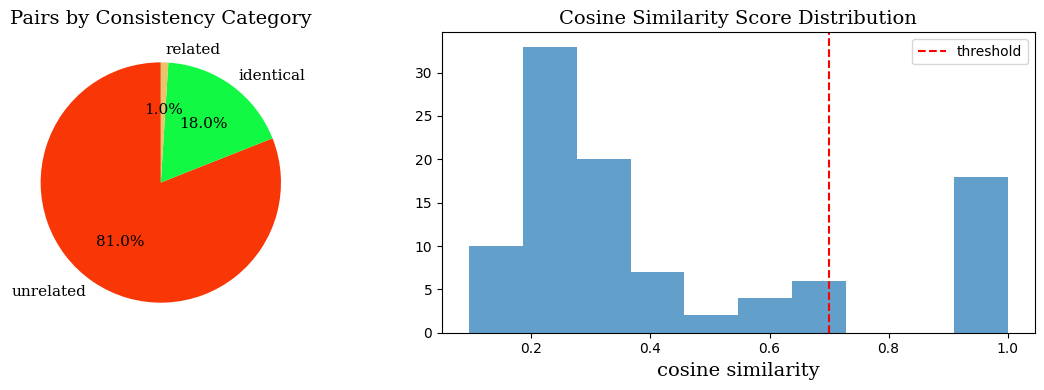

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title('Pairs by Consistency Category', fontname='serif', fontsize=14)
axes[0].pie(
    df['consistency_category'].value_counts(), 
    labels=df['consistency_category'].value_counts().index, 
    autopct='%1.1f%%',                         # Displays percentage inside the slices
    startangle=90,                             # Rotates the pie chart for a cleaner look
    colors=['#f93706', '#12f944', '#e9c46a'],  # Keeps your original custom colors
    textprops={'fontsize': 11, 'fontname' : 'serif'}                 # Adjusts the text size inside the chart
)

axes[1].hist(df["pred_cosine_sim"].dropna(), bins=10, alpha=0.7)
axes[1].axvline(bu.CONSISTENCY_COSINE_THRESHOLD, color="red", linestyle="--", label="threshold")
axes[1].set_title("Cosine Similarity Score Distribution", fontname='serif', fontsize=14)
axes[1].set_xlabel("cosine similarity", fontname='serif', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()
